# All-groups Diameter, Density, and Porosity Figures

This notebook reproduces the same data sources and model logic used in summary analysis, but reports results for all conditions (groups).

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

repo_root = Path("C:/Users/sthui4072/Github/fenestrations")
data_path = repo_root / "roi_data.pickle"
metafile_path = repo_root / "fenestrations_metafile.xlsx"
metrics_file = repo_root / "stub_profile_metrics_major_minor.xlsx"
union_summary_file = repo_root / "union_masks" / "union_mask_summary.csv"

for p in [data_path, metafile_path, metrics_file, union_summary_file]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

data = pd.read_pickle(data_path)
rois_df = data["rois"].copy()
summary_df = data["summary"].copy()
metadata = pd.read_excel(metafile_path)
metrics_df = pd.read_excel(metrics_file)
union_area_df = pd.read_csv(union_summary_file)

def _stub_key(value):
    if pd.isna(value):
        return None
    return "".join(ch for ch in str(value).upper() if ch.isalnum())

if "condition" not in metrics_df.columns:
    meta_lookup = (
        metadata[["stub", "condition"]]
        .dropna(subset=["stub", "condition"])
        .assign(_stub_key=lambda d: d["stub"].map(_stub_key))
        .drop_duplicates(subset=["_stub_key"], keep="first")
        [["_stub_key", "condition"]]
    )
    metrics_df = metrics_df.assign(_stub_key=metrics_df["stub"].map(_stub_key)).merge(
        meta_lookup,
        on="_stub_key",
        how="left"
    )

required_roi = ["stub", "condition", "diameter_area"]
required_summary = ["stub", "condition", "mean_neighbor_count", "mean_cluster_neighbor_distance_nm"]
required_union = ["stub", "covered_area_nm2", "covered_area_um2", "coverage_percent"]
required_metrics = ["stub", "condition", "major_p2p_nm", "minor_p2p_nm", "major_fwhm_nm", "minor_fwhm_nm", "major_derivative_nm", "minor_derivative_nm"]

for name, frame, cols in [
    ("rois_df", rois_df, required_roi),
    ("summary_df", summary_df, required_summary),
    ("union_area_df", union_area_df, required_union),
    ("metrics_df", metrics_df, required_metrics),
]:
    missing = [c for c in cols if c not in frame.columns]
    if missing:
        raise KeyError(f"{name} is missing columns: {missing}")

condition_order = sorted(rois_df["condition"].dropna().astype(str).unique().tolist())
palette = dict(zip(condition_order, sns.color_palette("Set2", n_colors=max(3, len(condition_order)))[:len(condition_order)]))

print("Conditions:", condition_order)
print("ROI rows:", len(rois_df), "| Summary rows:", len(summary_df), "| Metrics rows:", len(metrics_df))

Conditions: ['control', 'fasted', 'restricted']
ROI rows: 234865 | Summary rows: 548 | Metrics rows: 548


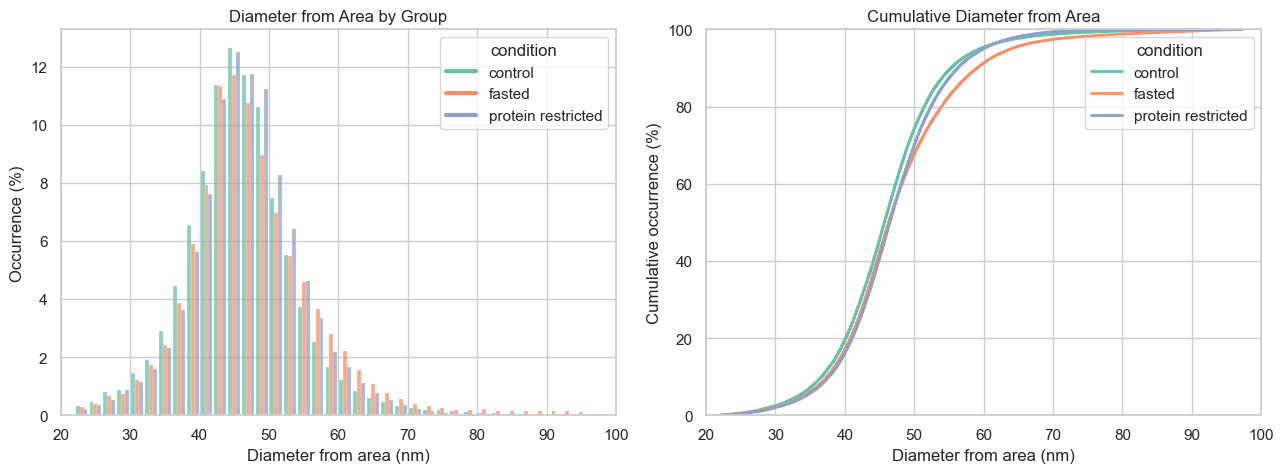

In [32]:
# Figure 1: Diameter from area for all groups (bar histogram + cumulative)
area_plot_df = rois_df[["condition", "diameter_area"]].dropna().copy()
area_plot_df = area_plot_df[area_plot_df["diameter_area"] > 0]

def legend_label(name):
    return "protein restricted" if name == "restricted" else name

legend_handles = [plt.Line2D([0], [0], color=palette[c], lw=3, label=legend_label(c)) for c in condition_order]
area_xlim = (20, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

sns.histplot(
    data=area_plot_df,
    x="diameter_area",
    hue="condition",
    hue_order=condition_order,
    bins=np.linspace(0, 120, 61),
    stat="percent",
    common_norm=False,
    multiple="dodge",
    element="bars",
    shrink=0.85,
    palette=palette,
    ax=axes[0],
)
axes[0].set_title("Diameter from Area by Group")
axes[0].set_xlabel("Diameter from area (nm)")
axes[0].set_ylabel("Occurrence (%)")
axes[0].set_xlim(area_xlim)
axes[0].legend(handles=legend_handles, title="condition")

# Draw fluent cumulative curves using sorted values and linear interpolation.
for condition in condition_order:
    vals = np.sort(area_plot_df.loc[area_plot_df["condition"] == condition, "diameter_area"].to_numpy())
    if len(vals) == 0:
        continue
    cum_pct = np.linspace(100.0 / len(vals), 100.0, len(vals))
    axes[1].plot(vals, cum_pct, color=palette[condition], linewidth=2, label=legend_label(condition))

axes[1].set_title("Cumulative Diameter from Area")
axes[1].set_xlabel("Diameter from area (nm)")
axes[1].set_ylabel("Cumulative occurrence (%)")
axes[1].set_ylim(0, 100)
axes[1].set_xlim(area_xlim)
axes[1].legend(title="condition")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

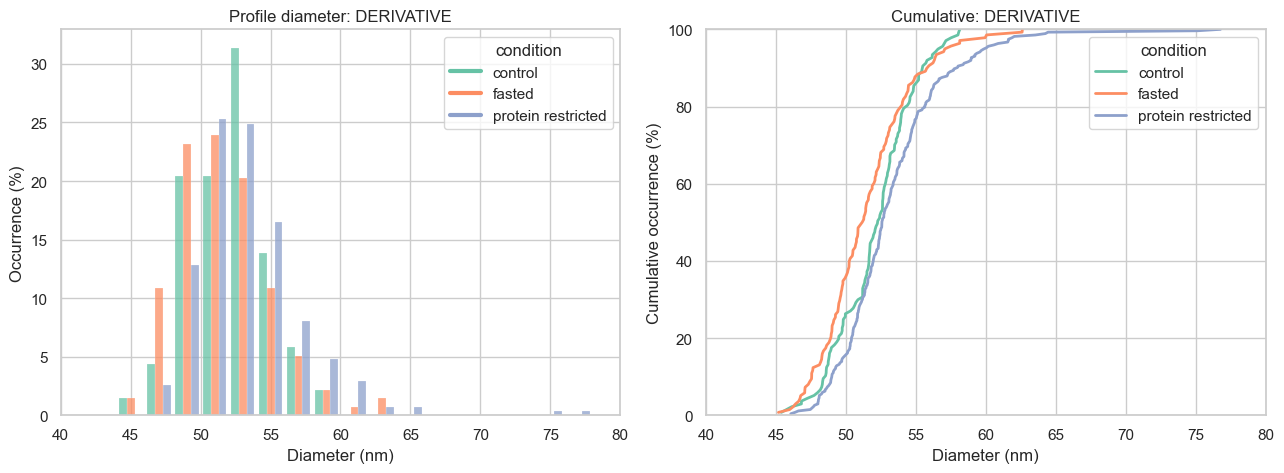

In [31]:
# Figure 2: Derivative diameter only (histogram + cumulative)
derivative_plot_df = metrics_df[["condition", "major_derivative_nm", "minor_derivative_nm"]].dropna().copy()
derivative_plot_df = derivative_plot_df[(derivative_plot_df["major_derivative_nm"] > 0) & (derivative_plot_df["minor_derivative_nm"] > 0)]
derivative_plot_df["diameter_nm"] = np.sqrt(
    derivative_plot_df["major_derivative_nm"] * derivative_plot_df["minor_derivative_nm"]
)

def legend_label(name):
    return "protein restricted" if name == "restricted" else name

legend_handles = [plt.Line2D([0], [0], color=palette[c], lw=3, label=legend_label(c)) for c in condition_order]
profile_xlim = (40, 80)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

sns.histplot(
    data=derivative_plot_df,
    x="diameter_nm",
    hue="condition",
    hue_order=condition_order,
    bins=np.linspace(0, 120, 61),
    stat="percent",
    common_norm=False,
    multiple="dodge",
    element="bars",
    shrink=0.85,
    palette=palette,
    ax=axes[0],
)
axes[0].set_title("Profile diameter: DERIVATIVE")
axes[0].set_xlabel("Diameter (nm)")
axes[0].set_ylabel("Occurrence (%)")
axes[0].set_xlim(profile_xlim)
axes[0].legend(handles=legend_handles, title="condition")

# Draw cumulative curves from sorted values.
for condition in condition_order:
    vals = np.sort(derivative_plot_df.loc[derivative_plot_df["condition"] == condition, "diameter_nm"].to_numpy())
    if len(vals) == 0:
        continue
    cum_pct = np.linspace(100.0 / len(vals), 100.0, len(vals))
    axes[1].plot(vals, cum_pct, color=palette[condition], linewidth=2, label=legend_label(condition))

axes[1].set_title("Cumulative: DERIVATIVE")
axes[1].set_xlabel("Diameter (nm)")
axes[1].set_ylabel("Cumulative occurrence (%)")
axes[1].set_ylim(0, 100)
axes[1].set_xlim(profile_xlim)
axes[1].legend(title="condition")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [23]:
# Build per-stub tables for all groups and compute lattice/union porosity+density
summary_stub = (
    summary_df[["stub", "condition", "mean_neighbor_count", "mean_cluster_neighbor_distance_nm"]]
    .dropna(subset=["stub", "condition", "mean_neighbor_count", "mean_cluster_neighbor_distance_nm"])
    .assign(_stub_key=lambda d: d["stub"].map(_stub_key))
    .drop_duplicates(subset=["_stub_key"], keep="first")
    .copy()
)

summary_stub["cell_area_square_nm2"] = summary_stub["mean_cluster_neighbor_distance_nm"] ** 2
summary_stub["cell_area_hex_nm2"] = (np.sqrt(3) / 2.0) * (summary_stub["mean_cluster_neighbor_distance_nm"] ** 2)
summary_stub["blend_weight"] = np.clip((summary_stub["mean_neighbor_count"] - 4.0) / 2.0, 0.0, 1.0)
summary_stub["cell_area_blend_nm2"] = (
    summary_stub["blend_weight"] * summary_stub["cell_area_hex_nm2"]
    + (1.0 - summary_stub["blend_weight"]) * summary_stub["cell_area_square_nm2"]
)

union_stub = (
    union_area_df[["stub", "covered_area_nm2", "covered_area_um2", "coverage_percent"]]
    .dropna(subset=["stub", "covered_area_nm2"])
    .assign(_stub_key=lambda d: d["stub"].map(_stub_key))
    .drop_duplicates(subset=["_stub_key"], keep="first")
    .copy()
)

roi_stub = rois_df[["stub", "condition", "diameter_area", "area"]].dropna(subset=["stub", "condition"]).copy()
roi_stub["area"] = pd.to_numeric(roi_stub["area"], errors="coerce")
roi_stub = roi_stub.dropna(subset=["area"])
roi_stub = roi_stub[roi_stub["area"] > 0]
roi_stub["_stub_key"] = roi_stub["stub"].map(_stub_key)

roi_stub_summary = (
    roi_stub.groupby(["_stub_key", "condition"], as_index=False)
    .agg(
        stub=("stub", "first"),
        roi_count=("area", "size"),
        mean_diameter_nm=("diameter_area", "mean"),
        mean_roi_area_nm2=("area", "mean"),
        total_roi_area_nm2=("area", "sum"),
    )
)

profile_stub_rows = []
for method, major_col, minor_col in method_specs:
    tmp = metrics_df[["stub", "condition", major_col, minor_col]].dropna().copy()
    tmp = tmp[(tmp[major_col] > 0) & (tmp[minor_col] > 0)]
    tmp["_stub_key"] = tmp["stub"].map(_stub_key)
    tmp["eq_diameter_nm"] = np.sqrt(tmp[major_col] * tmp[minor_col])
    tmp["eq_area_nm2"] = np.pi * (tmp["eq_diameter_nm"] / 2.0) ** 2
    tmp = (
        tmp.groupby(["_stub_key", "condition"], as_index=False)
        .agg(
            stub=("stub", "first"),
            mean_eq_diameter_nm=("eq_diameter_nm", "mean"),
            mean_eq_area_nm2=("eq_area_nm2", "mean"),
        )
    )
    tmp["method"] = method
    profile_stub_rows.append(tmp)

profile_stub = pd.concat(profile_stub_rows, ignore_index=True)

roi_counts = (
    rois_df[["stub", "condition"]]
    .dropna(subset=["stub", "condition"])
    .assign(_stub_key=lambda d: d["stub"].map(_stub_key))
    .groupby(["_stub_key", "condition"], as_index=False)
    .size()
    .rename(columns={"size": "roi_count"})
)

# Area-based model metrics
area_model = summary_stub.merge(roi_stub_summary, on=["_stub_key", "condition"], how="left")
area_model = area_model.merge(union_stub[["_stub_key", "covered_area_nm2", "covered_area_um2", "coverage_percent"]], on="_stub_key", how="left")

area_model["porosity_lattice"] = area_model["mean_roi_area_nm2"] / area_model["cell_area_blend_nm2"]
area_model["porosity_lattice_pct"] = area_model["porosity_lattice"] * 100.0
area_model["density_lattice_per_um2"] = (area_model["porosity_lattice"] / area_model["mean_roi_area_nm2"]) * 1_000_000.0

area_model["porosity_union"] = area_model["total_roi_area_nm2"] / area_model["covered_area_nm2"]
area_model["porosity_union_pct"] = area_model["porosity_union"] * 100.0
area_model["density_union_per_um2"] = (area_model["roi_count"] / area_model["covered_area_nm2"]) * 1_000_000.0

# Profile-based model metrics
profile_model = summary_stub.merge(profile_stub, on=["_stub_key", "condition"], how="left")
profile_model = profile_model.merge(roi_counts, on=["_stub_key", "condition"], how="left")
profile_model = profile_model.merge(union_stub[["_stub_key", "covered_area_nm2", "covered_area_um2", "coverage_percent"]], on="_stub_key", how="left")

profile_model["total_eq_area_nm2"] = profile_model["mean_eq_area_nm2"] * profile_model["roi_count"]
profile_model["porosity_lattice"] = profile_model["mean_eq_area_nm2"] / profile_model["cell_area_blend_nm2"]
profile_model["porosity_lattice_pct"] = profile_model["porosity_lattice"] * 100.0
profile_model["density_lattice_per_um2"] = (profile_model["porosity_lattice"] / profile_model["mean_eq_area_nm2"]) * 1_000_000.0

profile_model["porosity_union"] = profile_model["total_eq_area_nm2"] / profile_model["covered_area_nm2"]
profile_model["porosity_union_pct"] = profile_model["porosity_union"] * 100.0
profile_model["density_union_per_um2"] = (profile_model["roi_count"] / profile_model["covered_area_nm2"]) * 1_000_000.0

print("Area model stubs:", area_model["stub_x"].notna().sum())
print("Profile model rows:", len(profile_model))

Area model stubs: 548
Profile model rows: 548


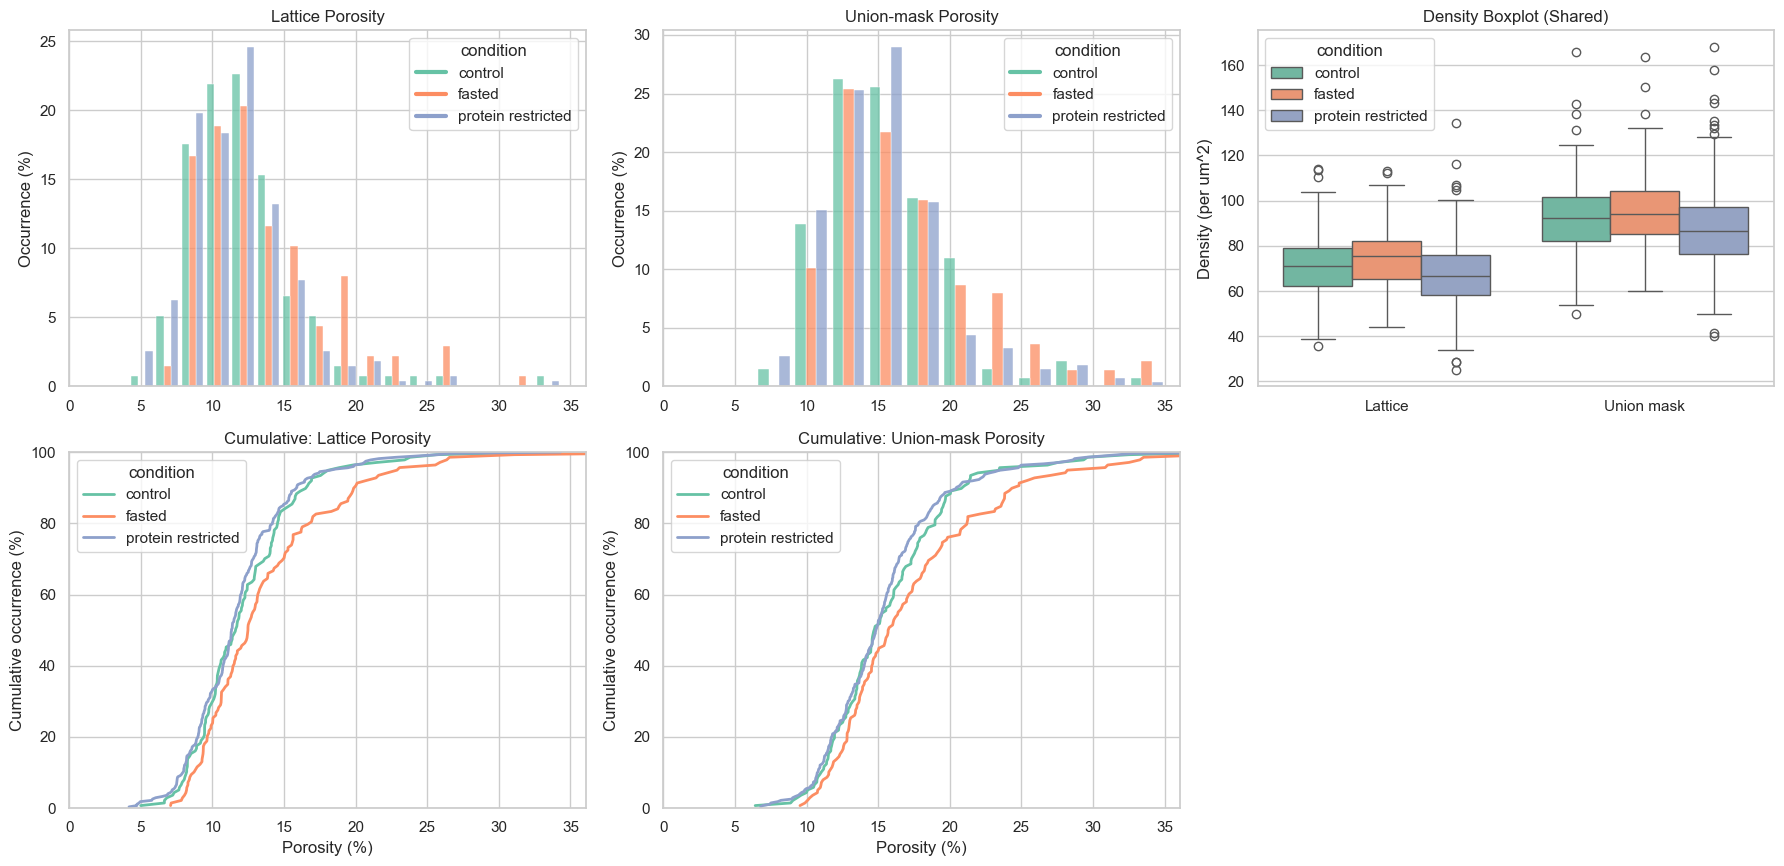

In [29]:
# Figure 3: Area-based porosity (bar + cumulative) + one shared density boxplot
area_plot = pd.concat([
    area_model[["condition", "porosity_lattice_pct", "density_lattice_per_um2"]]
    .rename(columns={"porosity_lattice_pct": "porosity_pct", "density_lattice_per_um2": "density_per_um2"})
    .assign(model="lattice"),
    area_model[["condition", "porosity_union_pct", "density_union_per_um2"]]
    .rename(columns={"porosity_union_pct": "porosity_pct", "density_union_per_um2": "density_per_um2"})
    .assign(model="union_mask"),
], ignore_index=True)

def legend_label(name):
    return "protein restricted" if name == "restricted" else name

# Use one shared porosity x-limit across area and profile figures.
all_porosity = pd.concat([
    area_model["porosity_lattice_pct"],
    area_model["porosity_union_pct"],
    profile_model["porosity_lattice_pct"],
    profile_model["porosity_union_pct"],
], ignore_index=True)
all_porosity = all_porosity.replace([np.inf, -np.inf], np.nan).dropna()
porosity_xmax = max(5.0, float(np.nanpercentile(all_porosity, 99.5)) * 1.05)
porosity_xlim = (0.0, porosity_xmax)
legend_handles = [plt.Line2D([0], [0], color=palette[c], lw=3, label=legend_label(c)) for c in condition_order]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex="col")

for col_idx, (model_name, title_base) in enumerate([
    ("lattice", "Lattice Porosity"),
    ("union_mask", "Union-mask Porosity"),
]):
    sub = area_plot[(area_plot["model"] == model_name) & area_plot["porosity_pct"].notna()].copy()

    sns.histplot(
        data=sub,
        x="porosity_pct",
        hue="condition",
        hue_order=condition_order,
        stat="percent",
        common_norm=False,
        multiple="dodge",
        element="bars",
        shrink=0.85,
        bins=24,
        palette=palette,
        ax=axes[0, col_idx],
    )
    axes[0, col_idx].set_title(title_base)
    axes[0, col_idx].set_xlabel("Porosity (%)")
    axes[0, col_idx].tick_params(axis="x", labelbottom=True)
    axes[0, col_idx].set_ylabel("Occurrence (%)")
    axes[0, col_idx].set_xlim(porosity_xlim)
    axes[0, col_idx].legend(handles=legend_handles, title="condition")

    # Fluent cumulative lines for porosity.
    for condition in condition_order:
        vals = np.sort(sub.loc[sub["condition"] == condition, "porosity_pct"].to_numpy())
        if len(vals) == 0:
            continue
        cum_pct = np.linspace(100.0 / len(vals), 100.0, len(vals))
        axes[1, col_idx].plot(vals, cum_pct, color=palette[condition], linewidth=2, label=legend_label(condition))

    axes[1, col_idx].set_title(f"Cumulative: {title_base}")
    axes[1, col_idx].set_xlabel("Porosity (%)")
    axes[1, col_idx].tick_params(axis="x", labelbottom=True)
    axes[1, col_idx].set_ylabel("Cumulative occurrence (%)")
    axes[1, col_idx].set_ylim(0, 100)
    axes[1, col_idx].set_xlim(porosity_xlim)
    axes[1, col_idx].legend(title="condition")

# Keep one shared density boxplot in the right column.
density_box = area_plot[area_plot["density_per_um2"].notna()].copy()
sns.boxplot(
    data=density_box,
    x="model",
    y="density_per_um2",
    hue="condition",
    order=["lattice", "union_mask"],
    hue_order=condition_order,
    palette=palette,
    ax=axes[0, 2],
)
axes[0, 2].set_title("Density Boxplot (Shared)")
axes[0, 2].set_xlabel("Density source (lattice vs union mask)")
axes[0, 2].set_xticks([0, 1])
axes[0, 2].set_xticklabels(["Lattice", "Union mask"])
axes[0, 2].tick_params(axis="x", labelbottom=True)
axes[0, 2].set_ylabel("Density (per um^2)")
handles_box, labels_box = axes[0, 2].get_legend_handles_labels()
labels_box = [legend_label(lbl) for lbl in labels_box]
axes[0, 2].legend(handles_box, labels_box, title="condition")

axes[1, 2].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

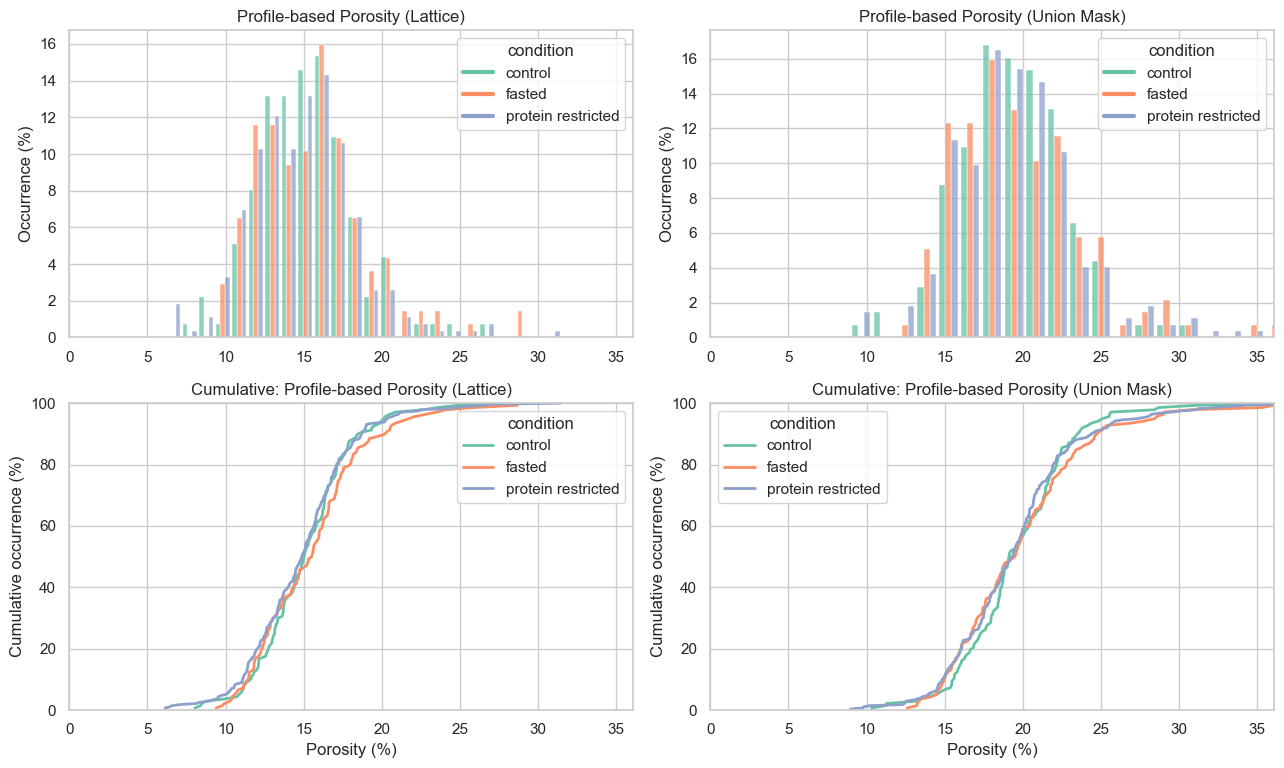

In [30]:
# Figure 4: Profile-based porosity by group (bar + cumulative)
profile_plot = pd.concat([
    profile_model[["condition", "method", "porosity_lattice_pct", "density_lattice_per_um2"]]
    .rename(columns={"porosity_lattice_pct": "porosity_pct", "density_lattice_per_um2": "density_per_um2"})
    .assign(model="lattice"),
    profile_model[["condition", "method", "porosity_union_pct", "density_union_per_um2"]]
    .rename(columns={"porosity_union_pct": "porosity_pct", "density_union_per_um2": "density_per_um2"})
    .assign(model="union_mask"),
], ignore_index=True)

def legend_label(name):
    return "protein restricted" if name == "restricted" else name

# Use one shared porosity x-limit across area and profile figures.
all_porosity = pd.concat([
    area_model["porosity_lattice_pct"],
    area_model["porosity_union_pct"],
    profile_model["porosity_lattice_pct"],
    profile_model["porosity_union_pct"],
], ignore_index=True)
all_porosity = all_porosity.replace([np.inf, -np.inf], np.nan).dropna()
porosity_xmax = max(5.0, float(np.nanpercentile(all_porosity, 99.5)) * 1.05)
porosity_xlim = (0.0, porosity_xmax)
legend_handles = [plt.Line2D([0], [0], color=palette[c], lw=3, label=legend_label(c)) for c in condition_order]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex="col")
for col_idx, (model_name, title_base) in enumerate([
    ("lattice", "Profile-based Porosity (Lattice)"),
    ("union_mask", "Profile-based Porosity (Union Mask)"),
]):
    sub = profile_plot[(profile_plot["model"] == model_name) & profile_plot["porosity_pct"].notna()].copy()

    sns.histplot(
        data=sub,
        x="porosity_pct",
        hue="condition",
        hue_order=condition_order,
        stat="percent",
        common_norm=False,
        multiple="dodge",
        element="bars",
        shrink=0.85,
        bins=24,
        palette=palette,
        ax=axes[0, col_idx],
    )
    axes[0, col_idx].set_title(title_base)
    axes[0, col_idx].set_xlabel("Porosity (%)")
    axes[0, col_idx].tick_params(axis="x", labelbottom=True)
    axes[0, col_idx].set_ylabel("Occurrence (%)")
    axes[0, col_idx].set_xlim(porosity_xlim)
    axes[0, col_idx].legend(handles=legend_handles, title="condition")

    # Fluent cumulative lines for porosity.
    for condition in condition_order:
        vals = np.sort(sub.loc[sub["condition"] == condition, "porosity_pct"].to_numpy())
        if len(vals) == 0:
            continue
        cum_pct = np.linspace(100.0 / len(vals), 100.0, len(vals))
        axes[1, col_idx].plot(vals, cum_pct, color=palette[condition], linewidth=2, label=legend_label(condition))

    axes[1, col_idx].set_title(f"Cumulative: {title_base}")
    axes[1, col_idx].set_xlabel("Porosity (%)")
    axes[1, col_idx].tick_params(axis="x", labelbottom=True)
    axes[1, col_idx].set_ylabel("Cumulative occurrence (%)")
    axes[1, col_idx].set_ylim(0, 100)
    axes[1, col_idx].set_xlim(porosity_xlim)
    axes[1, col_idx].legend(title="condition")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [17]:
# Optional summary tables
display(
    area_model[[
        "condition", "stub_x", "roi_count", "mean_diameter_nm",
        "porosity_lattice_pct", "density_lattice_per_um2",
        "porosity_union_pct", "density_union_per_um2"
    ]].sort_values(["condition", "stub_x"]).reset_index(drop=True)
)

display(
    profile_model[[
        "condition", "stub_x", "method", "mean_eq_diameter_nm",
        "porosity_lattice_pct", "density_lattice_per_um2",
        "porosity_union_pct", "density_union_per_um2"
    ]].sort_values(["condition", "method", "stub_x"]).reset_index(drop=True)
)

,condition,stub_x,roi_count,mean_diameter_nm,porosity_lattice_pct,density_lattice_per_um2,porosity_union_pct,density_union_per_um2
0,control,FAS6_ME_new_01,181,45.790531,15.569603,93.144192,4.559918,27.279431
1,control,FAS6_ME_new_04,178,51.107888,24.523933,113.994828,7.503090,34.876684
2,control,FAS6_ME_new_10,46,50.757400,15.245534,73.572441,1.635701,7.893625
3,control,FAS6_ME_new_31,26,43.440738,9.859185,65.505065,0.756513,5.026321
4,control,FAS6_ME_new_35,81,43.614531,12.555149,81.183232,2.148298,13.891175
...,...,...,...,...,...,...,...,...
173,restricted,PR6_ME_57,22,48.396237,11.765240,63.139466,1.150084,6.172056
174,restricted,PR9_ME_03,21,46.456143,7.865783,45.901344,0.775961,4.528174
175,restricted,PR9_ME_08,7,48.153989,8.455746,45.269523,1.390862,7.446256
176,restricted,PR9_ME_19,23,45.750129,9.883079,59.391429,0.930766,5.593353


,condition,stub_x,method,mean_eq_diameter_nm,porosity_lattice_pct,density_lattice_per_um2,porosity_union_pct,density_union_per_um2
0,control,FAS6_ME_new_01,derivative,51.426061,19.346936,93.144192,5.666198,27.279431
1,control,FAS6_ME_new_04,derivative,50.322550,22.672547,113.994828,6.936659,34.876684
2,control,FAS6_ME_new_10,derivative,53.475534,16.524005,73.572441,1.772869,7.893625
3,control,FAS6_ME_new_31,derivative,49.475308,12.593365,65.505065,0.966311,5.026321
4,control,FAS6_ME_new_35,derivative,52.856333,17.813542,81.183232,3.048056,13.891175
...,...,...,...,...,...,...,...,...
173,restricted,PR6_ME_57,derivative,54.752272,14.866032,63.139466,1.453195,6.172056
174,restricted,PR9_ME_03,derivative,53.517537,10.325415,45.901344,1.018604,4.528174
175,restricted,PR9_ME_08,derivative,50.204352,8.961455,45.269523,1.474044,7.446256
176,restricted,PR9_ME_19,derivative,55.642483,14.441977,59.391429,1.360113,5.593353
